# **1. Perkenalan Dataset**

Nama Siswa: **Akbar Fadhila**  
Proyek Akhir: **Membangun Sistem Machine Learning - Dicoding**  

### **Stroke Prediction Dataset**
Dataset ini digunakan untuk memprediksi apakah seorang pasien kemungkinan akan mengalami stroke berdasarkan parameter klinis dan demografis seperti jenis kelamin, usia, riwayat penyakit (hipertensi, penyakit jantung), status pernikahan, jenis pekerjaan, tipe tempat tinggal, kadar glukosa rata-rata, indeks massa tubuh (BMI), dan status merokok.

**Fitur-fitur dalam dataset:**
- `id`: Identifikasi unik pasien (akan dihapus karena tidak relevan untuk pemodelan)
- `gender`: Jenis kelamin ("Male", "Female", "Other")
- `age`: Usia pasien
- `hypertension`: 0 jika tidak memiliki hipertensi, 1 jika memiliki hipertensi
- `heart_disease`: 0 jika tidak memiliki penyakit jantung, 1 jika memiliki penyakit jantung
- `ever_married`: Status pernikahan ("No", "Yes")
- `work_type`: Jenis pekerjaan ("children", "Govt_jov", "Never_worked", "Private", "Self-employed")
- `Residence_type`: Tipe tempat tinggal ("Rural", "Urban")
- `avg_glucose_level`: Kadar glukosa rata-rata di darah
- `bmi`: Indeks massa tubuh (Body Mass Index)
- `smoking_status`: Status merokok ("formerly smoked", "never smoked", "smokes", "Unknown")
- `stroke`: Variabel target (1 jika mengalami stroke, 0 jika tidak)

# **2. Import Library**

Pada tahap ini, kita mengimpor pustaka yang dibutuhkan untuk memproses data, melakukan analisis statistik, memvisualisasikan data, dan membuat pipeline preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Preprocessing & Pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("Library berhasil diimpor!")

Library berhasil diimpor!


# **3. Memuat Dataset**

Tahap ini bertujuan untuk memuat dataset raw (`healthcare-dataset-stroke-data.csv`) ke dalam Pandas DataFrame untuk pemeriksaan awal.

In [2]:
# Tentukan path dataset mentah
dataset_path = "../namadataset_raw/healthcare-dataset-stroke-data.csv"

# Memuat dataset
df = pd.read_csv(dataset_path)

# Menampilkan 5 baris pertama
print("Tampilan 5 baris pertama dataset:")
display(df.head())

# Memeriksa informasi umum dataset
print("\nInformasi Struktur Dataset:")
df.info()

Tampilan 5 baris pertama dataset:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Informasi Struktur Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


# **4. Exploratory Data Analysis (EDA)**

Melakukan EDA untuk memahami karakteristik data, distribusi fitur, outlier, korelasi, dan mengidentifikasi penanganan data yang diperlukan.

Jumlah Missing Values per Kolom:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Deskripsi Statistik Fitur Numerik:


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28824\784637008.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='Set2')


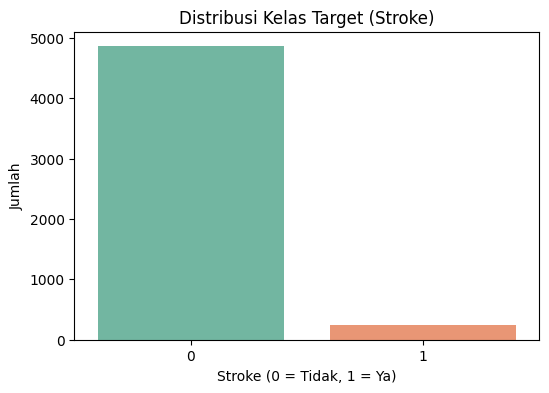

Persentase Kelas Target:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


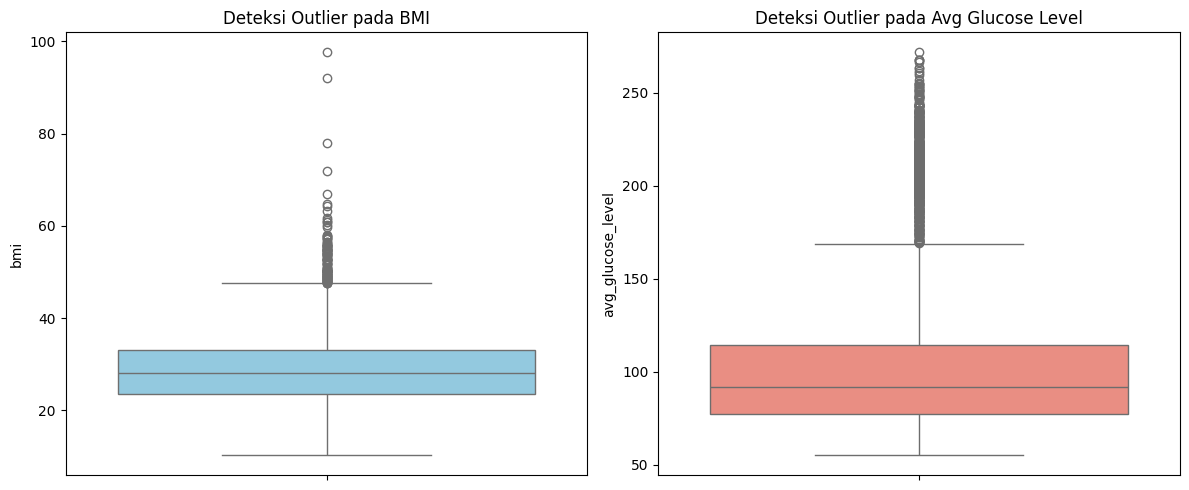

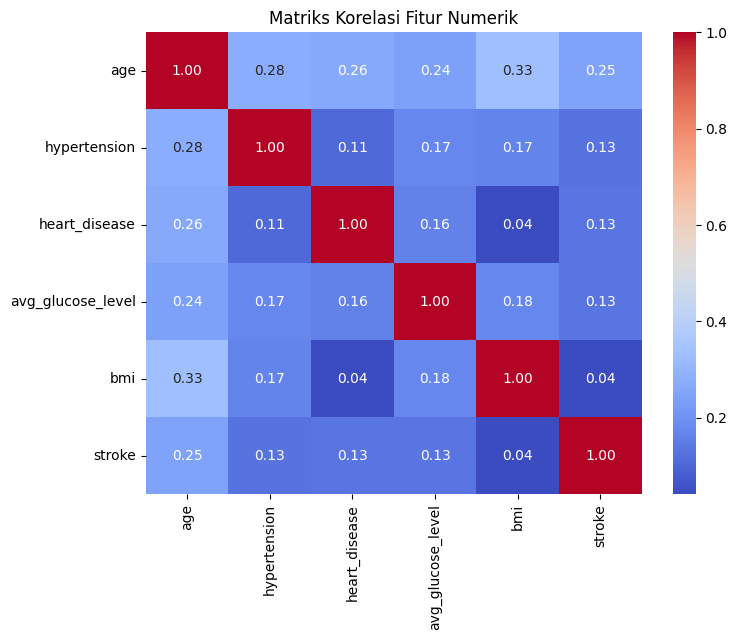

In [3]:
# 1. Memeriksa missing values
print("Jumlah Missing Values per Kolom:")
print(df.isnull().sum())

# 2. Memeriksa deskripsi statistik fitur numerik
print("\nDeskripsi Statistik Fitur Numerik:")
display(df.describe())

# 3. Distribusi Target Class (stroke)
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df, palette='Set2')
plt.title('Distribusi Kelas Target (Stroke)')
plt.xlabel('Stroke (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
plt.show()
print("Persentase Kelas Target:")
print(df['stroke'].value_counts(normalize=True) * 100)

# 4. Visualisasi Outlier untuk fitur BMI dan Avg Glucose Level
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y='bmi', data=df, ax=axes[0], color='skyblue')
axes[0].set_title('Deteksi Outlier pada BMI')
sns.boxplot(y='avg_glucose_level', data=df, ax=axes[1], color='salmon')
axes[1].set_title('Deteksi Outlier pada Avg Glucose Level')
plt.tight_layout()
plt.show()

# 5. Korelasi antar fitur numerik
plt.figure(figsize=(8, 6))
sns.heatmap(df[['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Fitur Numerik')
plt.show()

### **Temuan EDA:**
1. **Missing Values**: Fitur `bmi` memiliki missing values sebanyak 201 baris yang perlu ditangani menggunakan imputasi median.
2. **Outlier**: Fitur `bmi` dan `avg_glucose_level` memiliki nilai-nilai ekstrim (outliers) yang berada di luar rentang interkuartil. Kita perlu mempertimbangkan standarisasi untuk menstabilkan model.
3. **Data Imbalance**: Target `stroke` sangat tidak seimbang (imbalanced), di mana pasien yang terkena stroke hanya sekitar 4.87% dari total data. Hal ini krusial saat melatih model (diperlukan penanganan metric recall/F1-score atau teknik resampling saat modeling).
4. **Korelasi**: Usia (`age`) memiliki korelasi positif terbesar dengan `stroke` dibandingkan fitur numerik lainnya.

# **5. Data Preprocessing**

Tahap preprocessing meliputi:
1. Penghapusan kolom tidak relevan (`id`).
2. Penghapusan nilai anomali pada fitur kategorikal (`gender` bernilai 'Other' yang hanya ada 1 baris).
3. Pemisahan fitur independen (X) dan target (y).
4. Pembuatan pipeline transformasi data (Imputasi Median & Scaling untuk numerik, One-Hot Encoding untuk kategorikal).
5. Eksport hasil preprocessing ke folder `namadataset_preprocessing` agar siap dilatih.

In [4]:
# 1. Drop kolom id
df_clean = df.drop(columns=['id'])

# 2. Hapus baris dengan gender 'Other' (hanya 1 baris, merupakan anomali minor)
df_clean = df_clean[df_clean['gender'] != 'Other']

# 3. Pisahkan X dan y
X = df_clean.drop(columns=['stroke'])
y = df_clean['stroke']

# 4. Definisikan kolom numerik dan kategorikal
num_features = ['age', 'avg_glucose_level', 'bmi']
cat_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
bin_features = ['hypertension', 'heart_disease']

# 5. Buat transformer pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features),
    ('bin', 'passthrough', bin_features)
])

# 6. Terapkan preprocessing pipeline
X_preprocessed = preprocessor.fit_transform(X)

# Dapatkan nama fitur baru setelah OneHotEncoding
encoded_cat_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features)
all_feature_names = num_features + list(encoded_cat_features) + bin_features

# Buat dataframe preprocessed
df_preprocessed = pd.DataFrame(X_preprocessed, columns=all_feature_names)
df_preprocessed['stroke'] = y.reset_index(drop=True)

# 7. Simpan dataset hasil preprocessing
output_dir = "../preprocessing/namadataset_preprocessing"
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "stroke_data_preprocessed.csv")
df_preprocessed.to_csv(output_file, index=False)

print(f"Preprocessing selesai! Dataset preprocessed disimpan ke: {output_file}")
print("Bentuk data preprocessed:", df_preprocessed.shape)
display(df_preprocessed.head())

Preprocessing selesai! Dataset preprocessed disimpan ke: ../preprocessing/namadataset_preprocessing\stroke_data_preprocessed.csv
Bentuk data preprocessed: (5109, 21)


,age,avg_glucose_level,bmi,gender_Female,gender_Male,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,...,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,hypertension,heart_disease,stroke
0,1.051242,2.706450,1.004893,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1
1,0.785889,2.121652,-0.099142,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
2,1.626174,-0.004867,0.472358,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1
3,0.255182,1.437473,0.719142,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
4,1.581949,1.501297,-0.631677,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1
